# Análise Comparativa: Prim vs Kruskal
## Template de Jupyter Notebook para análise dos resultados

In [19]:
# ============================================================================
# CÉLULA 1: Imports e Configuração
# ============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [20]:
# ============================================================================
# CÉLULA 2: Carregar Dados
# ============================================================================
# Carregar resultados dos experimentos (arquivo em results/)
df = pd.read_csv('results/resultados_experimentos.csv')

# Visualizar primeiras linhas
print("Dados carregados:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColunas: {df.columns.tolist()}")

# Informações sobre os grafos
print("\nGrafos nos experimentos:")
print(df.groupby('graph_name').agg({
    'n_vertices': 'first',
    'n_edges': 'first',
    'repetition': 'count'
}))


Dados carregados:
  graph_name  n_vertices  n_edges algorithm  repetition  time_seconds  \
0     Grafo1        8980    12624      prim           1      0.027575   
1     Grafo1        8980    12624      prim           2      0.027475   
2     Grafo1        8980    12624      prim           3      0.025463   
3     Grafo1        8980    12624      prim           4      0.025697   
4     Grafo1        8980    12624      prim           5      0.025801   

   memory_mb  peak_memory_mb  cpu_seconds    mst_weight  mst_edges_count  \
0   0.621048        0.689911     0.031250  3.015372e+06             8979   
1   0.620148        0.689011     0.015625  3.015372e+06             8979   
2   0.498932        0.567795     0.031250  3.015372e+06             8979   
3   0.498932        0.567795     0.000000  3.015372e+06             8979   
4   0.498932        0.567795     0.031250  3.015372e+06             8979   

   valid                                     validation_msg  mem_rss_mb  \
0   True  ✓

In [21]:
# ============================================================================
# CÉLULA 3: Estatísticas Básicas
# ============================================================================
# Calcular médias por grafo e algoritmo
summary = df.groupby(['graph_name', 'algorithm']).agg({
    'time_seconds': ['mean', 'std', 'min', 'max'],
    'peak_memory_mb': ['mean', 'std', 'min', 'max'],
    'mst_weight': 'first',
    'mst_edges_count': 'first',
    'valid': 'all'
}).round(4)

print("Resumo estatístico:")
print(summary)

Resumo estatístico:
                     time_seconds                         peak_memory_mb  \
                             mean     std     min     max           mean   
graph_name algorithm                                                       
Grafo1     kruskal         0.0297  0.0003  0.0290  0.0303         0.7734   
           prim            0.0255  0.0008  0.0246  0.0279         0.5759   
Grafo2     kruskal         0.0166  0.0004  0.0160  0.0180         0.3888   
           prim            0.0134  0.0006  0.0130  0.0161         0.2717   

                                                mst_weight mst_edges_count  \
                         std     min     max         first           first   
graph_name algorithm                                                         
Grafo1     kruskal    0.0001  0.7733  0.7735  3.015372e+06            8979   
           prim       0.0309  0.5678  0.6899  3.015372e+06            8979   
Grafo2     kruskal    0.0000  0.3888  0.3888  2.641212e+0

In [22]:
# ============================================================================
# CÉLULA 4: Validação dos Resultados
# ============================================================================
# Verificar se ambos algoritmos produziram MSTs com mesmo peso
comparison = df.groupby(['graph_name', 'algorithm'])['mst_weight'].first().unstack()
comparison['diferenca'] = abs(comparison['prim'] - comparison['kruskal'])

print("\nComparação de pesos das MSTs:")
print(comparison)

# Verificar validade
print("\nTodas as MSTs válidas?")
print(df.groupby(['graph_name', 'algorithm'])['valid'].all())


Comparação de pesos das MSTs:
algorithm        kruskal          prim     diferenca
graph_name                                          
Grafo1      3.015372e+06  3.015372e+06  6.053597e-09
Grafo2      2.641212e+06  2.641212e+06  1.862645e-09

Todas as MSTs válidas?
graph_name  algorithm
Grafo1      kruskal      True
            prim         True
Grafo2      kruskal      True
            prim         True
Name: valid, dtype: bool


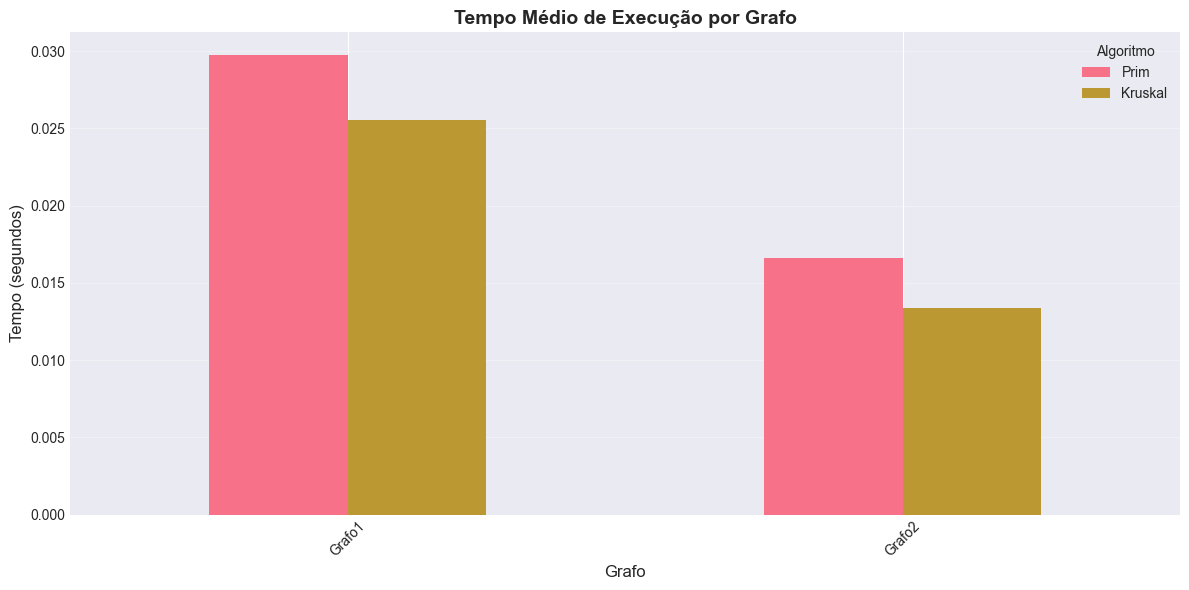

In [23]:
# ============================================================================
# CÉLULA 5: Gráfico - Tempo de Execução
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Calcular médias
avg_time = df.groupby(['graph_name', 'algorithm'])['time_seconds'].mean().unstack()

# Gráfico de barras
avg_time.plot(kind='bar', ax=ax)
ax.set_title('Tempo Médio de Execução por Grafo', fontsize=14, fontweight='bold')
ax.set_xlabel('Grafo', fontsize=12)
ax.set_ylabel('Tempo (segundos)', fontsize=12)
ax.legend(['Prim', 'Kruskal'], title='Algoritmo')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

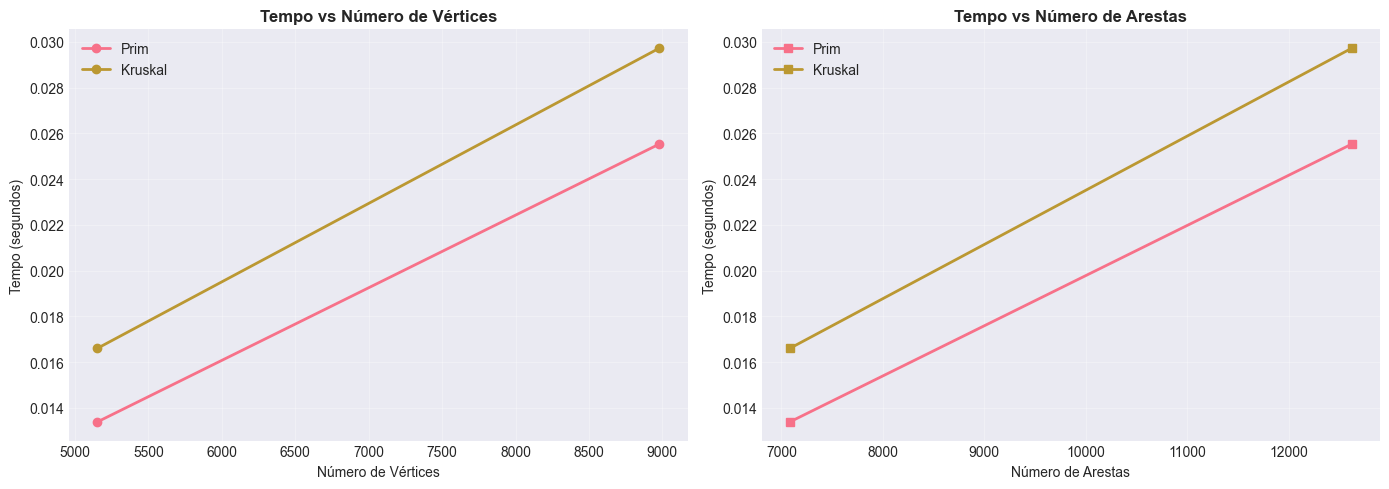

In [24]:
# ============================================================================
# CÉLULA 6: Gráfico - Tempo vs Tamanho do Grafo
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Por número de vértices
for algo in ['prim', 'kruskal']:
    data = df[df['algorithm'] == algo].groupby('n_vertices')['time_seconds'].mean()
    ax1.plot(data.index, data.values, marker='o', label=algo.capitalize(), linewidth=2)

ax1.set_title('Tempo vs Número de Vértices', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de Vértices')
ax1.set_ylabel('Tempo (segundos)')
ax1.legend()
ax1.grid(alpha=0.3)

# Por número de arestas
for algo in ['prim', 'kruskal']:
    data = df[df['algorithm'] == algo].groupby('n_edges')['time_seconds'].mean()
    ax2.plot(data.index, data.values, marker='s', label=algo.capitalize(), linewidth=2)

ax2.set_title('Tempo vs Número de Arestas', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Arestas')
ax2.set_ylabel('Tempo (segundos)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

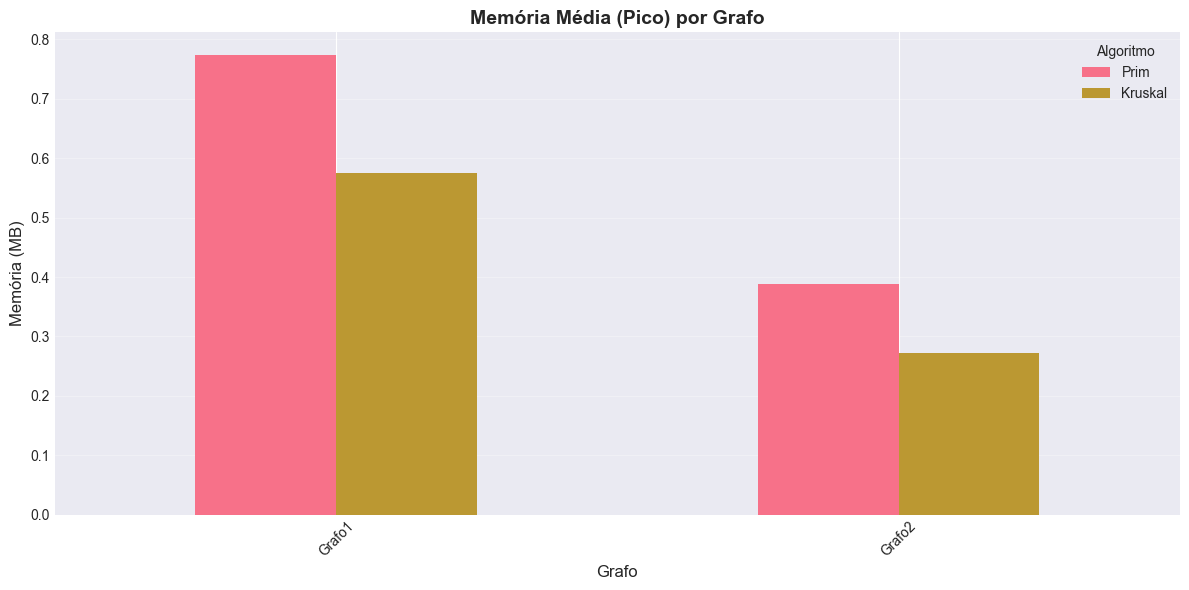

In [25]:
# ============================================================================
# CÉLULA 7: Gráfico - Memória
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

avg_memory = df.groupby(['graph_name', 'algorithm'])['peak_memory_mb'].mean().unstack()

avg_memory.plot(kind='bar', ax=ax)
ax.set_title('Memória Média (Pico) por Grafo', fontsize=14, fontweight='bold')
ax.set_xlabel('Grafo', fontsize=12)
ax.set_ylabel('Memória (MB)', fontsize=12)
ax.legend(['Prim', 'Kruskal'], title='Algoritmo')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

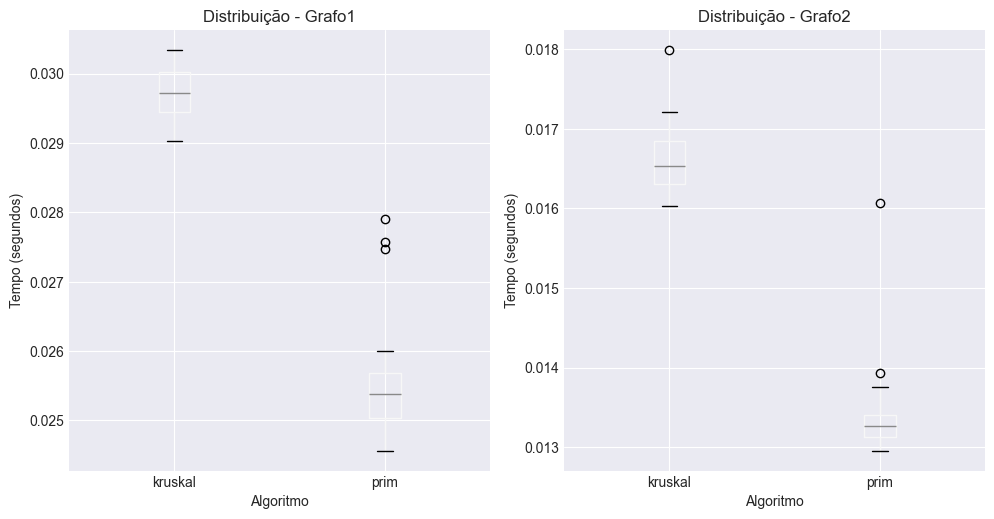

In [26]:
# ============================================================================
# CÉLULA 8: Boxplots - Distribuição dos Tempos
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

graphs = df['graph_name'].unique()

for i, graph in enumerate(graphs):
    if i >= len(axes):
        break
    
    data = df[df['graph_name'] == graph]
    
    # Boxplot
    data.boxplot(column='time_seconds', by='algorithm', ax=axes[i])
    axes[i].set_title(f'Distribuição - {graph}')
    axes[i].set_xlabel('Algoritmo')
    axes[i].set_ylabel('Tempo (segundos)')
    axes[i].get_figure().suptitle('')

# Remover subplots vazios
for i in range(len(graphs), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

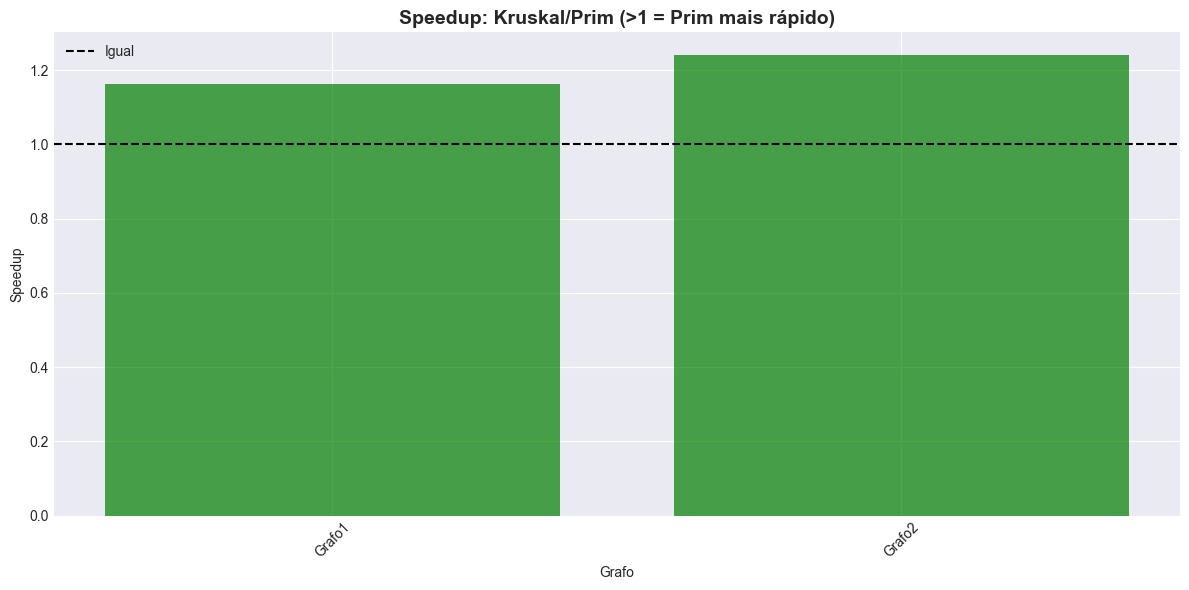


Speedup por grafo:
    graph   speedup mais_rapido
0  Grafo1  1.164161        Prim
1  Grafo2  1.240266        Prim


In [27]:
# ============================================================================
# CÉLULA 9: Speedup
# ============================================================================
# Calcular speedup (quanto um é mais rápido que o outro)
speedup_data = []

for graph in df['graph_name'].unique():
    prim_time = df[(df['graph_name'] == graph) & 
                   (df['algorithm'] == 'prim')]['time_seconds'].mean()
    kruskal_time = df[(df['graph_name'] == graph) & 
                      (df['algorithm'] == 'kruskal')]['time_seconds'].mean()
    
    speedup = kruskal_time / prim_time
    speedup_data.append({
        'graph': graph,
        'speedup': speedup,
        'mais_rapido': 'Prim' if speedup > 1 else 'Kruskal'
    })

speedup_df = pd.DataFrame(speedup_data)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['green' if s > 1 else 'red' for s in speedup_df['speedup']]
ax.bar(speedup_df['graph'], speedup_df['speedup'], color=colors, alpha=0.7)
ax.axhline(y=1, color='black', linestyle='--', label='Igual')
ax.set_title('Speedup: Kruskal/Prim (>1 = Prim mais rápido)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Grafo')
ax.set_ylabel('Speedup')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nSpeedup por grafo:")
print(speedup_df)

In [28]:
# ============================================================================
# CÉLULA 10: Conclusões
# ============================================================================
print("="*70)
print("CONCLUSÕES")
print("="*70)

# Algoritmo mais rápido em média
prim_avg = df[df['algorithm'] == 'prim']['time_seconds'].mean()
kruskal_avg = df[df['algorithm'] == 'kruskal']['time_seconds'].mean()

print(f"\nTempo médio geral:")
print(f"  Prim:    {prim_avg:.4f}s")
print(f"  Kruskal: {kruskal_avg:.4f}s")

if prim_avg < kruskal_avg:
    print(f"\n→ Prim foi {kruskal_avg/prim_avg:.2f}x mais rápido em média")
else:
    print(f"\n→ Kruskal foi {prim_avg/kruskal_avg:.2f}x mais rápido em média")

# Memória
prim_mem = df[df['algorithm'] == 'prim']['peak_memory_mb'].mean()
kruskal_mem = df[df['algorithm'] == 'kruskal']['peak_memory_mb'].mean()

print(f"\nMemória média (pico):")
print(f"  Prim:    {prim_mem:.2f} MB")
print(f"  Kruskal: {kruskal_mem:.2f} MB")

# Consistência
print(f"\nConsistência dos resultados:")
print(f"  Todas MSTs válidas: {df['valid'].all()}")
print(f"  Pesos idênticos: {(comparison['diferenca'] < 0.01).all()}")

print("\n" + "="*70)

CONCLUSÕES

Tempo médio geral:
  Prim:    0.0195s
  Kruskal: 0.0232s

→ Prim foi 1.19x mais rápido em média

Memória média (pico):
  Prim:    0.42 MB
  Kruskal: 0.58 MB

Consistência dos resultados:
  Todas MSTs válidas: True
  Pesos idênticos: True

